<a href="https://colab.research.google.com/github/DarkRai476/abcd/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BFS Traversal:
Bankura → Durgapur → Kolkata → Asansol → Dhanbad → Ranchi

DFS Traversal:
Bankura → Durgapur → Kolkata → Asansol → Dhanbad → Ranchi


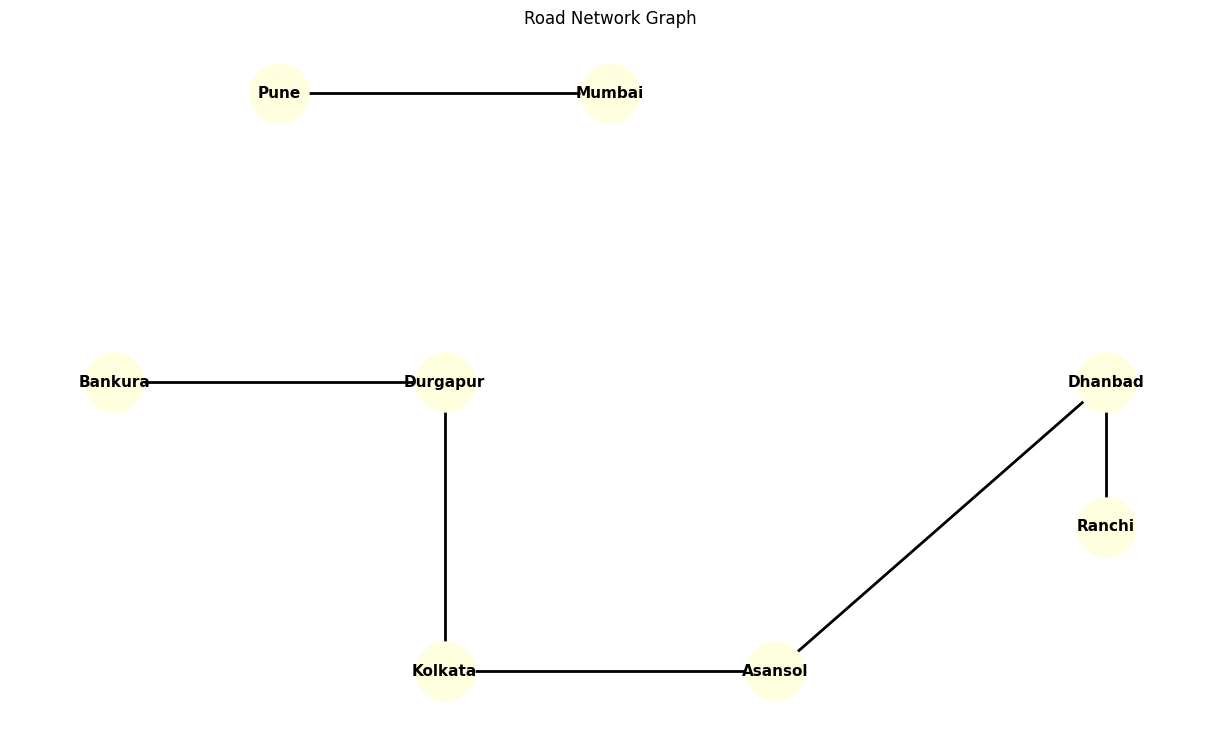

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# Road network
graph = {
    'Pune': ['Mumbai'],
    'Mumbai': ['Pune'],

    'Bankura': ['Durgapur'],
    'Durgapur': ['Bankura', 'Kolkata'],
    'Kolkata': ['Durgapur', 'Asansol'],
    'Asansol': ['Kolkata', 'Dhanbad'],
    'Dhanbad': ['Asansol', 'Ranchi'],
    'Ranchi': ['Dhanbad']
}


# ---------------- BFS ----------------
def bfs(graph, start):
    visited = set()
    queue = deque([start])
    result = []

    visited.add(start)

    while queue:
        city = queue.popleft()
        result.append(city)

        for neighbour in graph[city]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)

    return result


# ---------------- DFS ----------------
def dfs(graph, start, visited=None):
    if visited is None:
        visited = set()

    visited.add(start)
    result = [start]

    for neighbour in graph[start]:
        if neighbour not in visited:
            result.extend(dfs(graph, neighbour, visited))

    return result


# Starting city
start = 'Bankura'

print("BFS Traversal:")
print(" → ".join(bfs(graph, start)))

print("\nDFS Traversal:")
print(" → ".join(dfs(graph, start)))


# ---------------- Draw Graph ----------------
G = nx.Graph()

# Add roads
for city in graph:
    for neighbour in graph[city]:
        G.add_edge(city, neighbour)


# Position of cities similar to the given image
pos = {
    'Pune': (2, 5),
    'Mumbai': (4, 5),

    'Bankura': (1, 3),
    'Durgapur': (3, 3),
    'Kolkata': (3, 1),
    'Asansol': (5, 1),
    'Dhanbad': (7, 3),
    'Ranchi': (7, 2)
}


# Draw graph
plt.figure(figsize=(12, 7))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1800,
    node_color='lightyellow',
    edge_color='black',
    font_size=11,
    font_weight='bold',
    width=2
)

plt.title("Road Network Graph")
plt.axis('off')
plt.show()